#Import Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [2]:
!unzip dataset.zip -d /content/dataset

Archive:  dataset.zip
  inflating: /content/dataset/Logos.txt  
  inflating: /content/dataset/file_mapping.csv  
  inflating: /content/dataset/genLogoOutput/Adidas/000001.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/000002.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/000003.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/000004.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/000005.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/scal_000001.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/scal_000002.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/scal_000003.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/scal_000004.jpg  
  inflating: /content/dataset/genLogoOutput/Adidas/scal_000005.jpg  
  inflating: /content/dataset/genLogoOutput/Amazon/000001.jpg  
  inflating: /content/dataset/genLogoOutput/Amazon/000002.jpg  
  inflating: /content/dataset/genLogoOutput/Amazon/000003.jpg  
  inflating: /content/dataset/

In [6]:
import os
os.listdir('/content/dataset') #returns a list of all files and folders


['Logos.txt', 'genLogoOutput', 'output', 'file_mapping.csv']

In [8]:
!mkdir -p /content/dataset/train/real
!mkdir -p /content/dataset/train/fake



In [10]:
import os
os.listdir('/content/dataset') #returns a list of all files and folders


['Logos.txt', 'genLogoOutput', 'output', 'train', 'file_mapping.csv']

In [12]:
!mv /content/dataset/output/* /content/dataset/train/real/
!mv /content/dataset/genLogoOutput/* /content/dataset/train/fake/


In [13]:
import os

real_count = len(os.listdir('/content/dataset/train/real'))
fake_count = len(os.listdir('/content/dataset/train/fake'))

print(f"Real logos: {real_count}")
print(f"Fake logos: {fake_count}")


Real logos: 63
Fake logos: 63


In [14]:
#import library
#build CNN using TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


#Data Preprocessing step

In [25]:
#Loads images from your folders
train_dir = '/content/dataset/train'


Create an ImageDataGenerator

In [26]:
# Image data generator for training
#Applies transformations (called data augmentation) to improve model learning.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   # 80% train, 20% validation
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)


In [27]:
# Training data (teaches the model)
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 660 images belonging to 2 classes.


In [24]:
# Validation data (tests the model’s performance after each training epoch)
val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 165 images belonging to 2 classes.


#Model Building (CNN Architecture)

In [28]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification (real/fake)
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#perform model compilation to define the optimizer, loss function, and evaluation metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [30]:
#start learning from the training images, and check your progress after each round.
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5846 - loss: 0.7405 - val_accuracy: 0.6667 - val_loss: 0.5535
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6651 - loss: 0.5487 - val_accuracy: 0.6788 - val_loss: 0.5104
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6656 - loss: 0.5200 - val_accuracy: 0.7152 - val_loss: 0.4864
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7112 - loss: 0.4828 - val_accuracy: 0.7030 - val_loss: 0.4877
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7096 - loss: 0.4854 - val_accuracy: 0.7030 - val_loss: 0.4857
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7184 - loss: 0.4758 - val_accuracy: 0.6909 - val_loss: 0.5043
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7044 - loss: 0.4834 - val_accuracy: 0.7636 - val_loss: 0.4571
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7759 - loss: 0.4487 - val_accuracy: 0.7333 - val_loss:

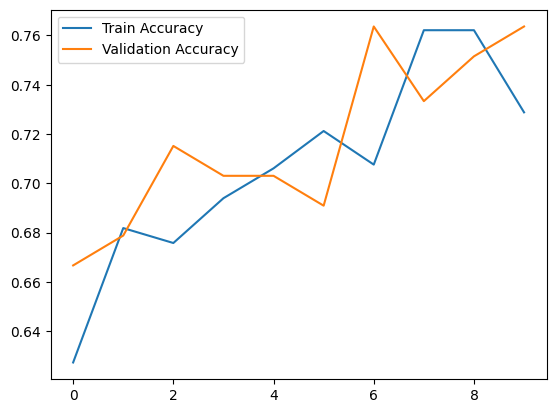

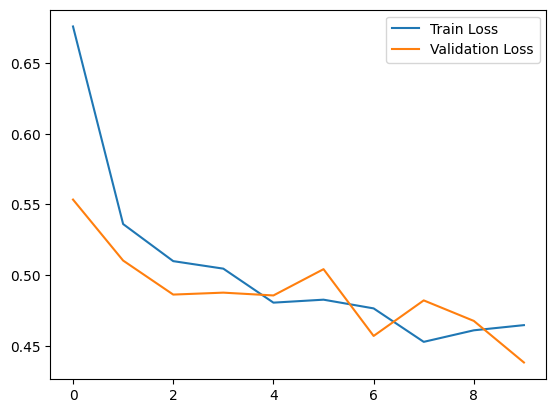

In [32]:
#Training Result Visualization
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()


In [33]:
#Data Verification
import os

# list a few sample images
real_images = os.listdir('/content/dataset/train/real')[:5]
fake_images = os.listdir('/content/dataset/train/fake')[:5]

print("Real:", real_images)
print("Fake:", fake_images)


Real: ['Lg', 'Fila', 'Google', 'YouTube', 'Levis']
Fake: ['Lg', 'Fila', 'Google', 'YouTube', 'Levis']


In [34]:
#Data Verification (per class)

import os

# Example: list images from real logos of 'Lg'
sample_real_images = os.listdir('/content/dataset/train/real/Lg')[:5]
sample_fake_images = os.listdir('/content/dataset/train/fake/Lg')[:5]

print("Sample real:", sample_real_images)
print("Sample fake:", sample_fake_images)


Sample real: ['000005.jpg', '000001.jpg', '000003.jpg', '000004.jpg']
Sample fake: ['000005.jpg', 'scal_000004.jpg', '000001.jpg', 'scal_000001.jpg', 'scal_000003.jpg']


#Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


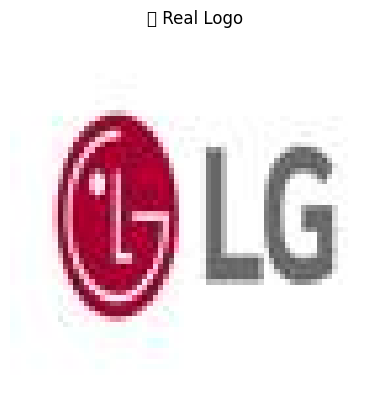

In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 🔹 Example: test a real logo image
img_path = '/content/dataset/train/real/Lg/000001.jpg'  # Change folder name if needed

# Load and preprocess
test_image = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(test_image)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict
prediction = model.predict(img_array)

# Output result
if prediction[0][0] > 0.5:
    label = "✅ Real Logo"
else:
    label = "❌ Fake Logo"

# Show image and label
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title(label)
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


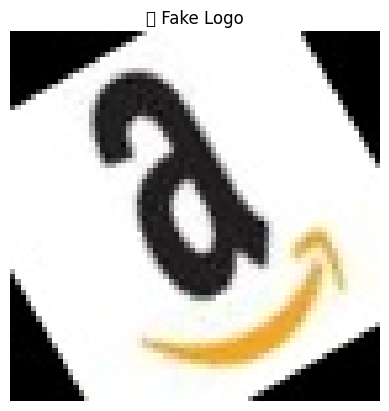

In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 🔹 Example: test a real logo image
img_path = '/content/dataset/train/fake/Amazon/000001.jpg'  # Change folder name if needed

# Load and preprocess
test_image = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(test_image)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict
prediction = model.predict(img_array)

# Output result
if prediction[0][0] > 0.5:
    label = "✅ Real Logo"
else:
    label = "❌ Fake Logo"

# Show image and label
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title(label)
plt.axis('off')
plt.show()


Confusion Matrix

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get ground truth and predictions from validation generator
val_data.reset()
predictions = model.predict(val_data)
pred_labels = (predictions > 0.5).astype(int).ravel()
true_labels = val_data.classes

# Compute confusion matrix and report
cm = confusion_matrix(true_labels, pred_labels)
cr = classification_report(true_labels, pred_labels, target_names=['Fake', 'Real'])

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 502ms/step
Confusion Matrix:
 [[80 30]
 [39 16]]

Classification Report:
               precision    recall  f1-score   support

        Fake       0.67      0.73      0.70       110
        Real       0.35      0.29      0.32        55

    accuracy                           0.58       165
   macro avg       0.51      0.51      0.51       165
weighted avg       0.56      0.58      0.57       165



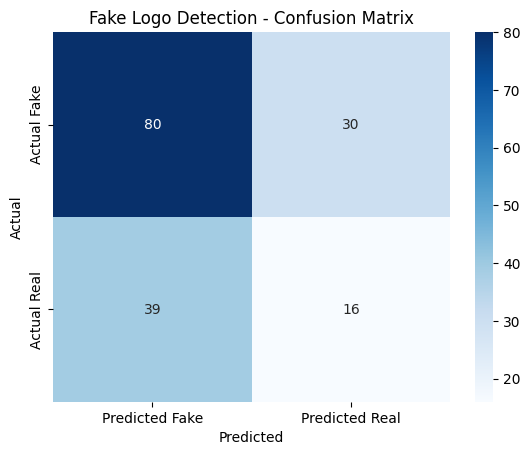

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fake Logo Detection - Confusion Matrix")
plt.show()
